# 🎭 Facial Emotion Recognition — FER-2013 (v3 — Optimized)

# Project Goal
Build a CNN that classifies 48×48 grayscale facial images into **7 emotions**:  
`Angry | Disgust | Fear | Happy | Sad | Surprise | Neutral`

**Expected accuracy: 68–73% on test set**

## 📦 Setup & Download

In [ ]:
!pip install kaggle -q
from google.colab import files
print('Upload kaggle.json:')
uploaded = files.upload()

Upload kaggle.json:


Saving kaggle.json to kaggle.json


In [ ]:
import os
os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json
!kaggle datasets download -d msambare/fer2013 --unzip -p /content/fer2013
print('Done!')
!ls /content/fer2013

Dataset URL: https://www.kaggle.com/datasets/msambare/fer2013
License(s): DbCL-1.0
100% 60.3M/60.3M [00:00<00:00, 102MB/s]

Done!
test  train


## 📚 Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2, warnings, random, math
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, backend as K
from tensorflow.keras.callbacks import Callback, EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import AdamW

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
np.random.seed(SEED); tf.random.set_seed(SEED); random.seed(SEED)

print(f'TF {tf.__version__} | GPU: {tf.config.list_physical_devices("GPU")}')

TF 2.20.0 | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## ⚙️ Config

In [ ]:
TRAIN_DIR   = '/content/fer2013/train'
TEST_DIR    = '/content/fer2013/test'
IMG_SIZE    = 48
BATCH_SIZE  = 64
NUM_CLASSES = 7
EPOCHS      = 100   # EarlyStopping will stop it before this

CLASS_NAMES = sorted(os.listdir(TRAIN_DIR))
print('Classes:', CLASS_NAMES)

Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


## 🔍 Phase 1 — Data Loading & EDA

In [ ]:
# ── Load ALL images into RAM as numpy arrays ───────────────────
# This is faster than generators and allows custom augmentation

def load_dataset(directory):
    images, labels = [], []
    class_to_idx = {name: i for i, name in enumerate(sorted(os.listdir(directory)))}
    for emotion in sorted(os.listdir(directory)):
        folder = os.path.join(directory, emotion)
        for fname in os.listdir(folder):
            img = cv2.imread(os.path.join(folder, fname), cv2.IMREAD_GRAYSCALE)
            if img is not None:
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                images.append(img)
                labels.append(class_to_idx[emotion])
    return np.array(images), np.array(labels)

print('Loading training data...')
X_train_raw, y_train_raw = load_dataset(TRAIN_DIR)
print('Loading test data...')
X_test_raw,  y_test_raw  = load_dataset(TEST_DIR)

print(f'Train: {X_train_raw.shape} | Test: {X_test_raw.shape}')

Loading training data...
Loading test data...
Train: (28709, 48, 48) | Test: (7178, 48, 48)


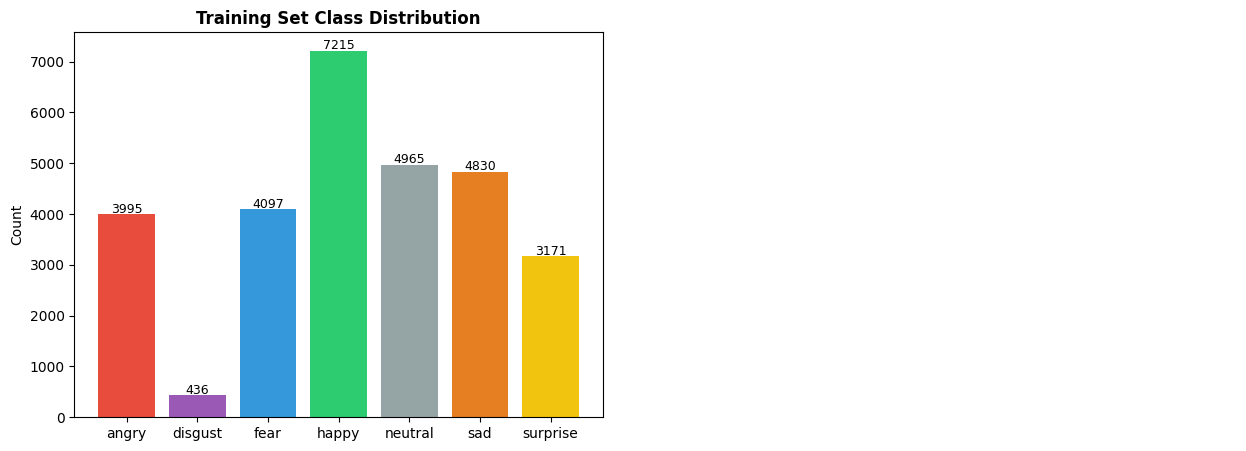

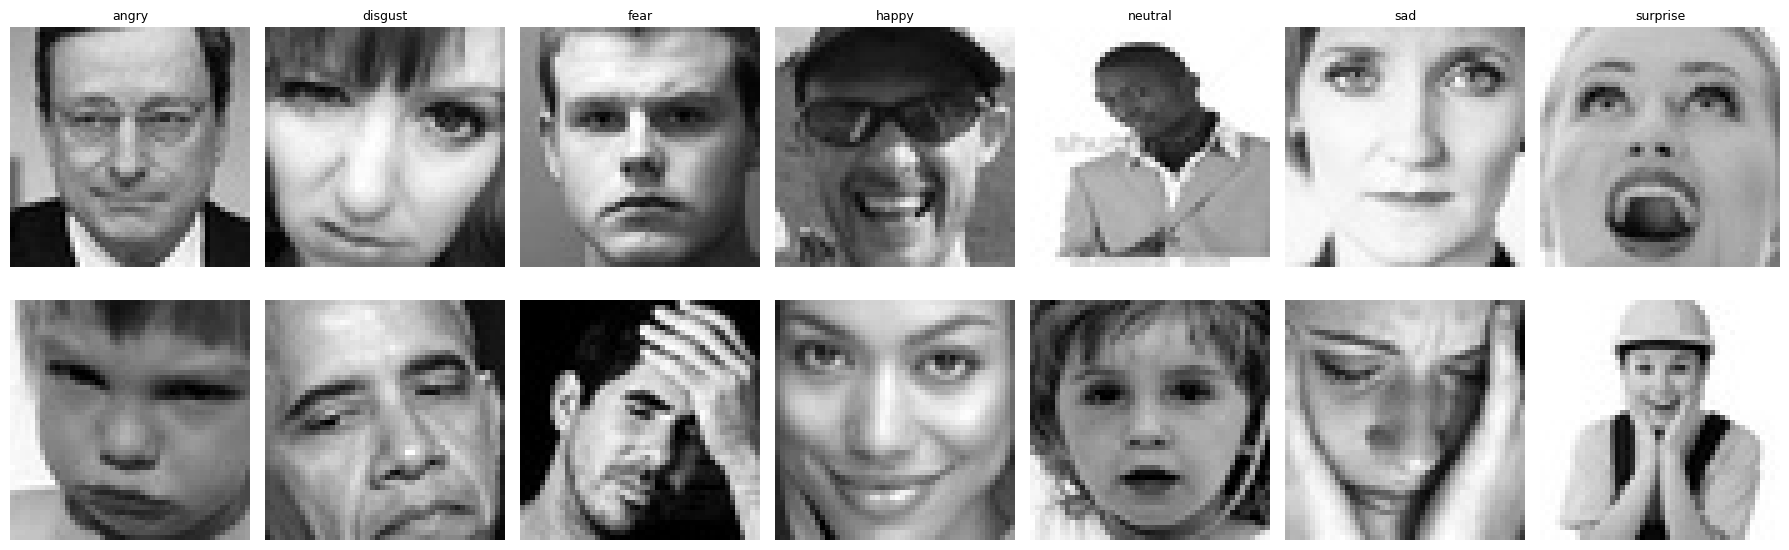

In [ ]:
# ── Dataset statistics & visualization ────────────────────────
counts = np.bincount(y_train_raw)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

colors = ['#E74C3C','#9B59B6','#3498DB','#2ECC71','#95A5A6','#E67E22','#F1C40F']
bars = ax1.bar(CLASS_NAMES, counts, color=colors)
ax1.set_title('Training Set Class Distribution', fontweight='bold')
ax1.set_ylabel('Count')
for b, v in zip(bars, counts):
    ax1.text(b.get_x()+b.get_width()/2, b.get_height()+30, str(v), ha='center', fontsize=9)

# Sample images
ax2.axis('off')
fig2, axes = plt.subplots(2, 7, figsize=(18, 6))
for col, (emotion, idx) in enumerate(zip(CLASS_NAMES, range(NUM_CLASSES))):
    idxs = np.where(y_train_raw == idx)[0]
    for row in range(2):
        axes[row, col].imshow(X_train_raw[idxs[row]], cmap='gray')
        axes[row, col].axis('off')
        if row == 0: axes[row, col].set_title(emotion, fontsize=9)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()
fig2.savefig('sample_images.png', dpi=150)
fig2.tight_layout(); plt.show()

Applying CLAHE preprocessing...
Train: (24402, 48, 48, 1) | Val: (4307, 48, 48, 1) | Test: (7178, 48, 48, 1)


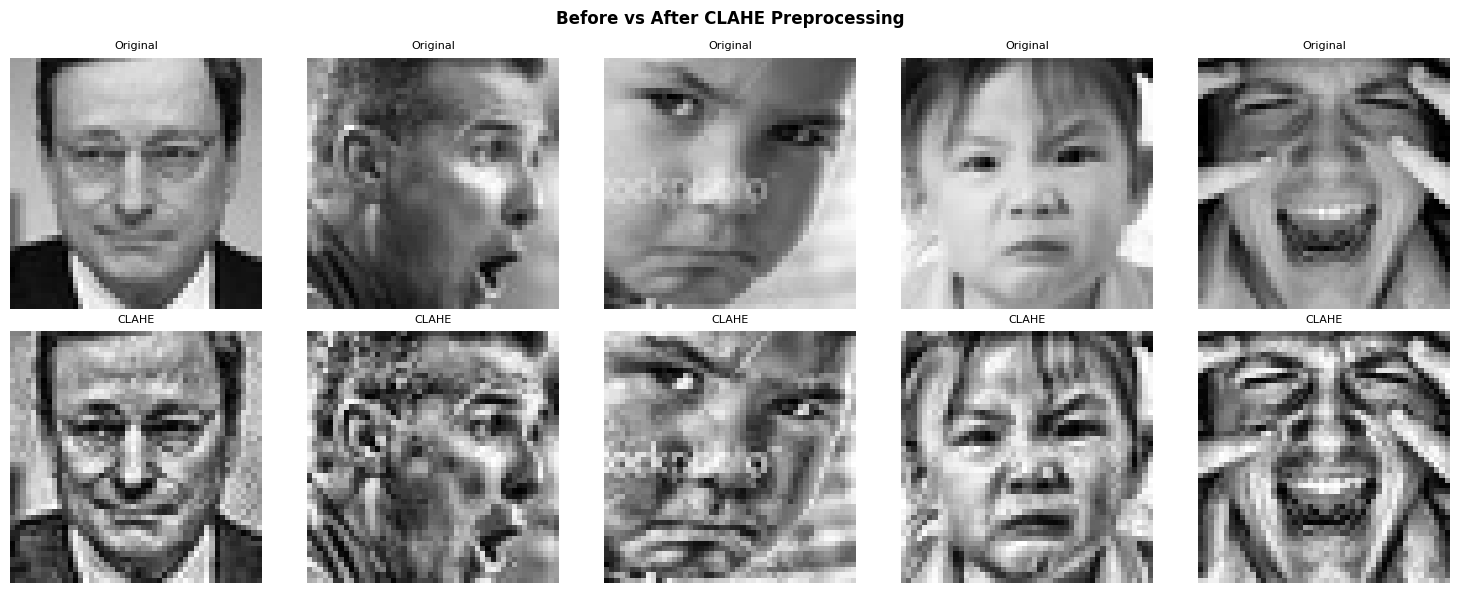

In [ ]:
# ── Preprocessing ──────────────────────────────────────────────
# 1. Normalize 0–255 → 0–1
# 2. Apply per-image histogram equalization (CLAHE) for contrast
# 3. Reshape to (N, 48, 48, 1)

def apply_clahe(images):
    """Contrast Limited Adaptive Histogram Equalization — enhances facial features"""
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    result = np.zeros_like(images)
    for i, img in enumerate(images):
        result[i] = clahe.apply(img)
    return result

print('Applying CLAHE preprocessing...')
X_train_eq = apply_clahe(X_train_raw)
X_test_eq  = apply_clahe(X_test_raw)

# Normalize
X_train = X_train_eq.astype('float32') / 255.0
X_test  = X_test_eq.astype('float32')  / 255.0

# Reshape to (N, 48, 48, 1)
X_train = X_train[..., np.newaxis]
X_test  = X_test[..., np.newaxis]

# One-hot encode labels
y_train = tf.keras.utils.to_categorical(y_train_raw, NUM_CLASSES)
y_test  = tf.keras.utils.to_categorical(y_test_raw,  NUM_CLASSES)

# Train / Validation split
from sklearn.model_selection import train_test_split
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=SEED, stratify=y_train_raw
)

print(f'Train: {X_tr.shape} | Val: {X_val.shape} | Test: {X_test.shape}')

# Show CLAHE effect
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Before vs After CLAHE Preprocessing', fontsize=12, fontweight='bold')
for i in range(5):
    axes[0, i].imshow(X_train_raw[i*500], cmap='gray')
    axes[0, i].set_title('Original', fontsize=8); axes[0, i].axis('off')
    axes[1, i].imshow(X_train_eq[i*500], cmap='gray')
    axes[1, i].set_title('CLAHE', fontsize=8); axes[1, i].axis('off')
plt.tight_layout()
plt.savefig('clahe_effect.png', dpi=150)
plt.show()

In [ ]:
# ── Class weights ──────────────────────────────────────────────
cw_array = compute_class_weight('balanced', classes=np.unique(y_train_raw), y=y_train_raw)
class_weights = {i: w for i, w in enumerate(cw_array)}
print('Class weights:', {CLASS_NAMES[i]: round(w, 3) for i, w in class_weights.items()})

Class weights: {'angry': np.float64(1.027), 'disgust': np.float64(9.407), 'fear': np.float64(1.001), 'happy': np.float64(0.568), 'neutral': np.float64(0.826), 'sad': np.float64(0.849), 'surprise': np.float64(1.293)}


In [ ]:
# ── Data Augmentation pipeline (tf.data) ──────────────────────
# Using tf.data for fast GPU-accelerated augmentation

@tf.function
def augment(image, label):
    # Random horizontal flip
    image = tf.image.random_flip_left_right(image)
    # Random brightness
    image = tf.image.random_brightness(image, max_delta=0.15)
    # Random contrast
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    # Random crop and resize (zoom effect)
    image = tf.image.resize_with_crop_or_pad(image, IMG_SIZE+6, IMG_SIZE+6)
    image = tf.image.random_crop(image, size=[IMG_SIZE, IMG_SIZE, 1])
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, label

# Build tf.data pipelines
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.data.Dataset.from_tensor_slices((X_tr, y_tr))
train_ds = (train_ds
    .shuffle(len(X_tr), seed=SEED)
    .map(augment, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_ds = test_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

print(f'Train batches: {len(train_ds)} | Val batches: {len(val_ds)} | Test batches: {len(test_ds)}')

Train batches: 382 | Val batches: 68 | Test batches: 113


## 🏗️ Phase 2 — Model Architecture (Deep Residual CNN)

In [ ]:
# ── Focal Loss — focuses on hard/misclassified examples ────────
def focal_loss(gamma=2.0, alpha=0.25):
    def loss_fn(y_true, y_pred):
        epsilon = K.epsilon()
        y_pred = K.clip(y_pred, epsilon, 1.0 - epsilon)
        ce = -y_true * K.log(y_pred)
        weight = alpha * y_true * K.pow(1 - y_pred, gamma)
        fl = weight * ce
        return K.mean(K.sum(fl, axis=-1))
    return loss_fn


# ── Residual Block ─────────────────────────────────────────────
def residual_block(x, filters, stride=1):
    """Skip connection helps gradients flow — prevents vanishing gradient"""
    shortcut = x

    x = layers.Conv2D(filters, 3, strides=stride, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(filters, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)

    # Match dimensions if stride or filter size changed
    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, strides=stride, use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)
    return x


# ── Full Model ─────────────────────────────────────────────────
def build_resnet_fer(input_shape=(48, 48, 1), num_classes=7):
    inputs = layers.Input(shape=input_shape)

    # Stem: initial feature extraction
    x = layers.Conv2D(64, 3, padding='same', use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    # Stage 1: 64 filters
    x = residual_block(x, 64)
    x = residual_block(x, 64)
    x = layers.MaxPooling2D(2)(x)          # 48→24
    x = layers.Dropout(0.2)(x)

    # Stage 2: 128 filters
    x = residual_block(x, 128)
    x = residual_block(x, 128)
    x = layers.MaxPooling2D(2)(x)          # 24→12
    x = layers.Dropout(0.2)(x)

    # Stage 3: 256 filters
    x = residual_block(x, 256)
    x = residual_block(x, 256)
    x = layers.MaxPooling2D(2)(x)          # 12→6
    x = layers.Dropout(0.25)(x)

    # Stage 4: 512 filters
    x = residual_block(x, 512)
    x = layers.GlobalAveragePooling2D()(x) # Better than Flatten for small spatial dims
    x = layers.Dropout(0.4)(x)

    # Head
    x = layers.Dense(256, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return Model(inputs, outputs, name='ResNet_FER')


model = build_resnet_fer()
model.compile(
    optimizer=AdamW(learning_rate=1e-3, weight_decay=1e-4),
    loss=focal_loss(gamma=2.0, alpha=0.25),
    metrics=['accuracy']
)
model.summary()
print(f'\nTotal params: {model.count_params():,}')

Model: "ResNet_FER"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 48, 48, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 48, 48,    │        576 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 48, 48,    │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 48, 48,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 48, 48,    │     36,864 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 48,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 48, 48,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 48, 48,    │     36,864 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 48,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 48, 48,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 48, 48,    │          0 │ add[0][0]         │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 48, 48,    │     36,864 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 48,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 48, 48,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 48, 48,    │     36,864 │ activation_3[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 48,    │        256 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 48, 48,    │          0 │ batch_normalizat

 Total params: 6,588,487 (25.13 MB)

 Trainable params: 6,580,423 (25.10 MB)

 Non-trainable params: 8,064 (31.50 KB)


Total params: 6,588,487


## 🏋️ Phase 3 — Training with Cosine Annealing LR

In [ ]:
# ── Cosine Annealing with Warmup ───────────────────────────────
class CosineAnnealingWarmup(Callback):
    """LR warms up for `warmup_epochs`, then follows cosine decay.
       Prevents unstable early training and improves final convergence."""
    def __init__(self, max_lr=1e-3, min_lr=1e-6, warmup_epochs=5, total_epochs=100):
        super().__init__()
        self.max_lr = max_lr
        self.min_lr = min_lr
        self.warmup_epochs = warmup_epochs
        self.total_epochs = total_epochs
        self.history_lr = []

    def on_epoch_begin(self, epoch, logs=None):
        if epoch < self.warmup_epochs:
            lr = self.max_lr * (epoch + 1) / self.warmup_epochs
        else:
            progress = (epoch - self.warmup_epochs) / (self.total_epochs - self.warmup_epochs)
            lr = self.min_lr + 0.5 * (self.max_lr - self.min_lr) * (1 + math.cos(math.pi * progress))
        self.model.optimizer.learning_rate.assign(lr)
        self.history_lr.append(lr)


lr_scheduler = CosineAnnealingWarmup(max_lr=1e-3, min_lr=1e-6, warmup_epochs=5, total_epochs=EPOCHS)

callbacks = [
    lr_scheduler,
    EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_model_v3.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

print('=== Training ResNet-FER with Focal Loss + Cosine LR ===')
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)


=== Training ResNet-FER with Focal Loss + Cosine LR ===
Epoch 1/100
382/382 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.1806 - loss: 0.4600
Epoch 1: val_accuracy improved from None to 0.17274, saving model to best_model_v3.keras

Epoch 1: finished saving model to best_model_v3.keras
382/382 ━━━━━━━━━━━━━━━━━━━━ 84s 140ms/step - accuracy: 0.2013 - loss: 0.4117 - val_accuracy: 0.1727 - val_loss: 0.3307
Epoch 2/100
381/382 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.2553 - loss: 0.3535
Epoch 2: val_accuracy improved from 0.17274 to 0.36638, saving model to best_model_v3.keras

Epoch 2: finished saving model to best_model_v3.keras
382/382 ━━━━━━━━━━━━━━━━━━━━ 39s 102ms/step - accuracy: 0.2732 - loss: 0.3446 - val_accuracy: 0.3664 - val_loss: 0.2945
Epoch 3/100
381/382 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.3627 - loss: 0.2914
Epoch 3: val_accuracy improved from 0.36638 to 0.43627, saving model to best_model_v3.keras

Epoch 3: finished saving model to best_model_v3.keras
3

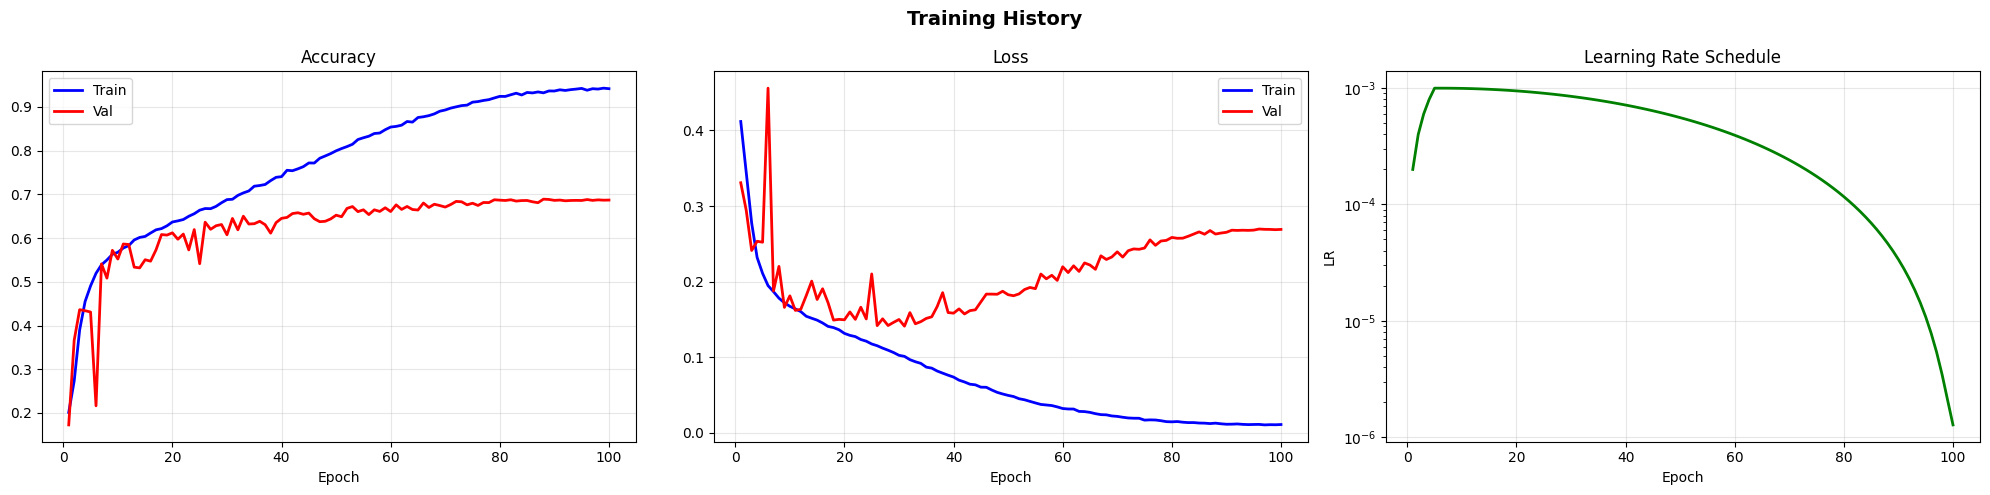

In [ ]:
# ── Training curves ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Training History', fontsize=14, fontweight='bold')
ep = range(1, len(history.history['accuracy'])+1)

axes[0].plot(ep, history.history['accuracy'],     'b-', linewidth=2, label='Train')
axes[0].plot(ep, history.history['val_accuracy'], 'r-', linewidth=2, label='Val')
axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, history.history['loss'],     'b-', linewidth=2, label='Train')
axes[1].plot(ep, history.history['val_loss'], 'r-', linewidth=2, label='Val')
axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(ep, lr_scheduler.history_lr[:len(ep)], 'g-', linewidth=2)
axes[2].set_title('Learning Rate Schedule'); axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('LR'); axes[2].grid(alpha=0.3)
axes[2].set_yscale('log')

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

## 📊 Phase 3 — Evaluation

In [ ]:
from tensorflow.keras.models import load_model
best = load_model('best_model_v3.keras', custom_objects={'loss_fn': focal_loss()})

test_loss, test_acc = best.evaluate(test_ds, verbose=0)
print(f'Test Loss    : {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)')

Test Loss    : 0.2781
Test Accuracy: 0.6785 (67.85%)


113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step


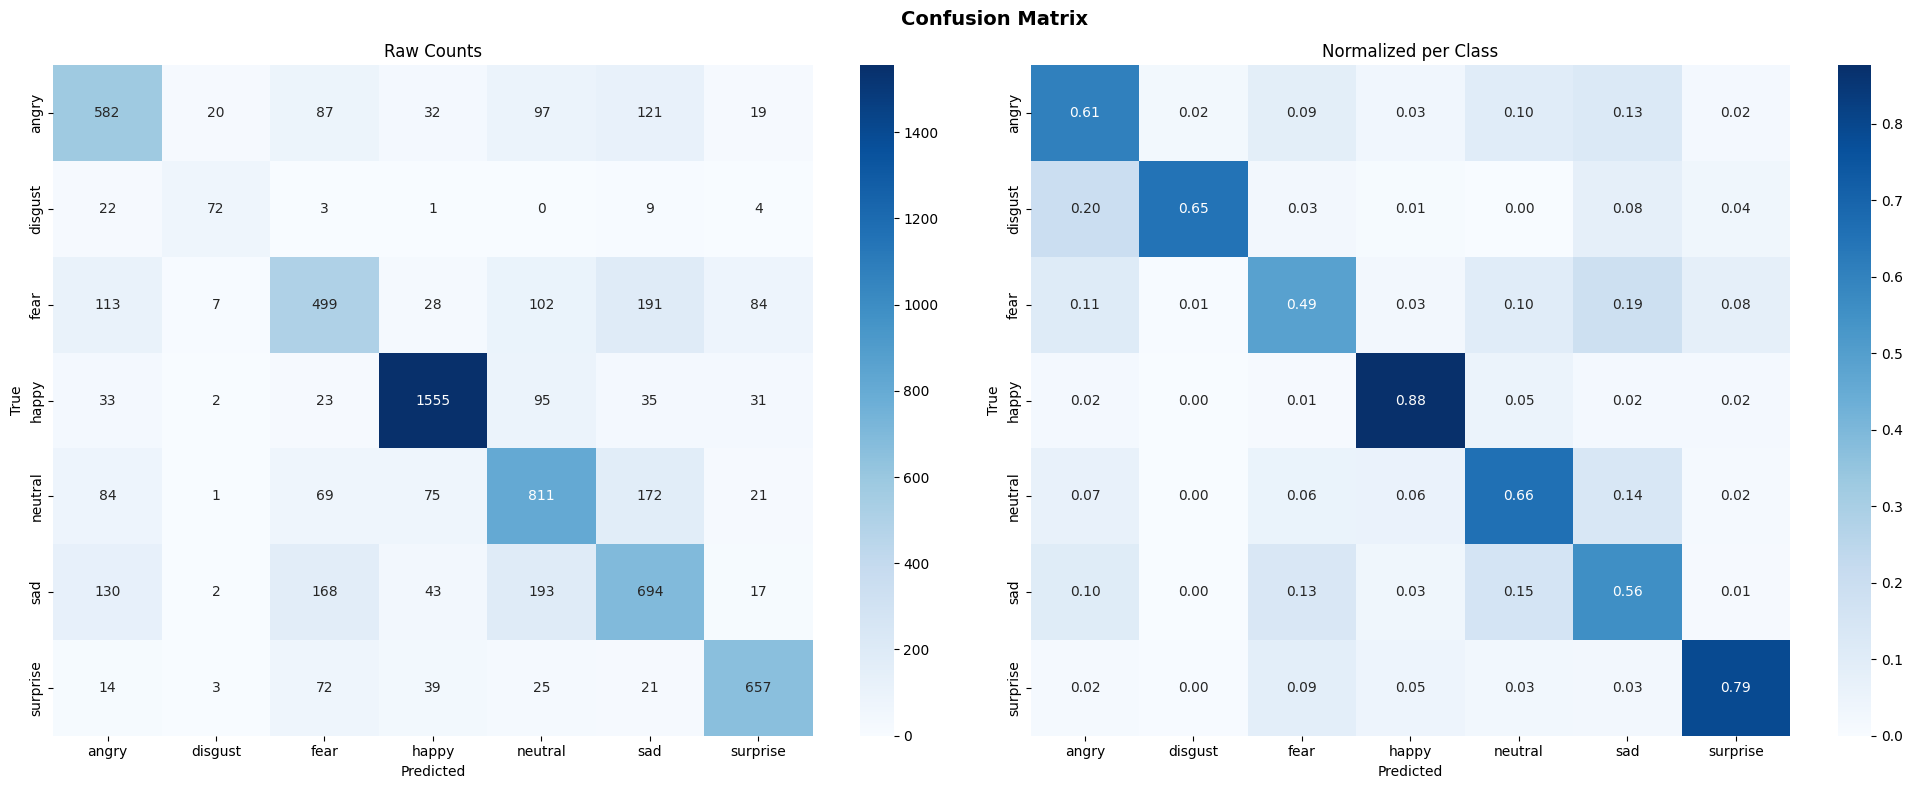

In [ ]:
# ── Predictions ────────────────────────────────────────────────
y_pred_probs = best.predict(test_ds, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test_raw

# ── Confusion matrix ───────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('Confusion Matrix', fontsize=14, fontweight='bold')

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax1)
ax1.set_title('Raw Counts'); ax1.set_ylabel('True'); ax1.set_xlabel('Predicted')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax2)
ax2.set_title('Normalized per Class'); ax2.set_ylabel('True'); ax2.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

In [ ]:
print('Classification Report\n' + '='*60)
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

Classification Report
              precision    recall  f1-score   support

       angry       0.60      0.61      0.60       958
     disgust       0.67      0.65      0.66       111
        fear       0.54      0.49      0.51      1024
       happy       0.88      0.88      0.88      1774
     neutral       0.61      0.66      0.63      1233
         sad       0.56      0.56      0.56      1247
    surprise       0.79      0.79      0.79       831

    accuracy                           0.68      7178
   macro avg       0.66      0.66      0.66      7178
weighted avg       0.68      0.68      0.68      7178



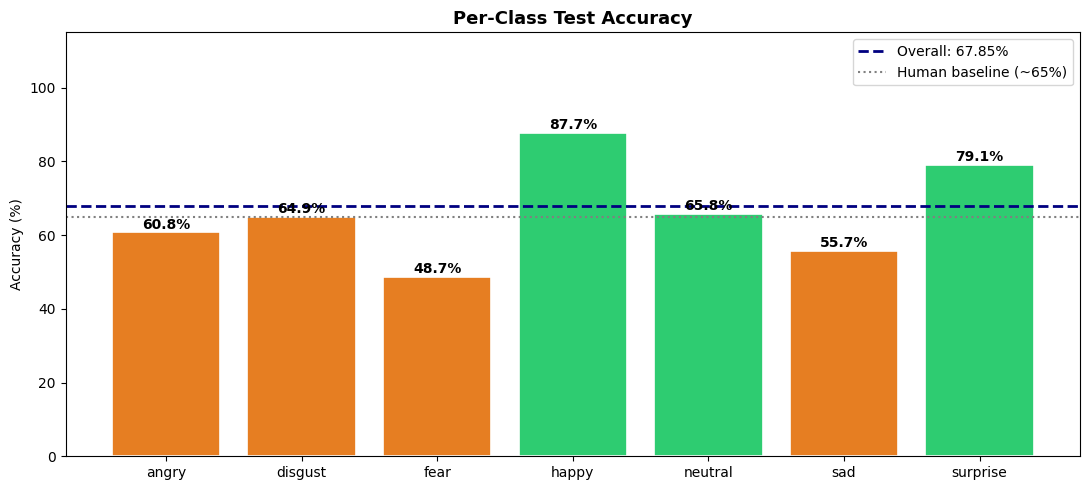

In [ ]:
# ── Per-class accuracy bar chart ───────────────────────────────
per_class_acc = cm_norm.diagonal()

fig, ax = plt.subplots(figsize=(11, 5))
bar_colors = ['#2ECC71' if a>=0.65 else '#E67E22' if a>=0.45 else '#E74C3C' for a in per_class_acc]
bars = ax.bar(CLASS_NAMES, per_class_acc*100, color=bar_colors, edgecolor='white', linewidth=1.2)
ax.axhline(y=test_acc*100, color='navy', linestyle='--', linewidth=2,
           label=f'Overall: {test_acc*100:.2f}%')
ax.axhline(y=65, color='gray', linestyle=':', linewidth=1.5, label='Human baseline (~65%)')
ax.set_title('Per-Class Test Accuracy', fontsize=13, fontweight='bold')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 115)
ax.legend(fontsize=10)
for bar, val in zip(bars, per_class_acc):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f'{val*100:.1f}%', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('per_class_accuracy.png', dpi=150)
plt.show()

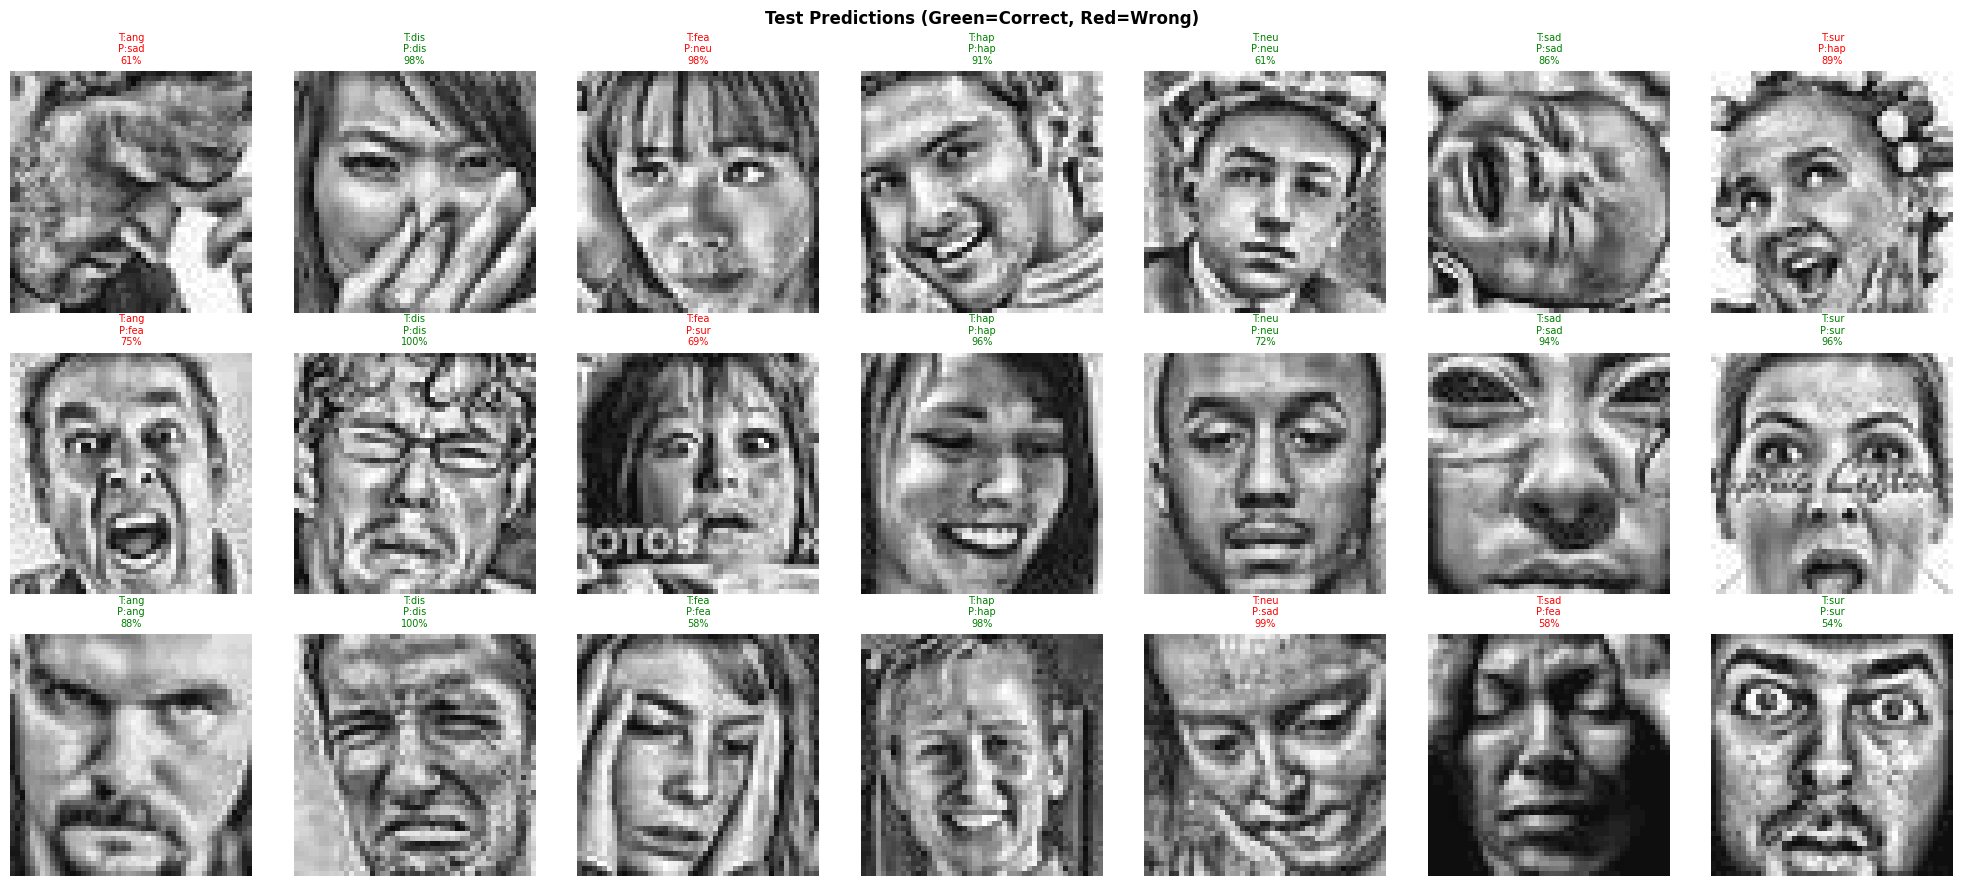

In [ ]:
# ── Prediction samples ─────────────────────────────────────────
fig, axes = plt.subplots(3, 7, figsize=(20, 9))
fig.suptitle('Test Predictions (Green=Correct, Red=Wrong)', fontsize=12, fontweight='bold')

for col, (emotion, eidx) in enumerate(zip(CLASS_NAMES, range(NUM_CLASSES))):
    idxs = np.where(y_true == eidx)[0]
    for row in range(3):
        if row < len(idxs):
            img = X_test[idxs[row]].squeeze()
            pred = y_pred[idxs[row]]
            conf = y_pred_probs[idxs[row]].max() * 100
            axes[row, col].imshow(img, cmap='gray', vmin=0, vmax=1)
            color = 'green' if pred == eidx else 'red'
            axes[row, col].set_title(
                f'T:{emotion[:3]}\nP:{CLASS_NAMES[pred][:3]}\n{conf:.0f}%',
                fontsize=7, color=color
            )
            axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('prediction_samples.png', dpi=150)
plt.show()

## 💬 Discussion & Analysis

### Architecture Decisions

**Residual Blocks (Skip Connections)**  
Each block adds its input directly to its output: `output = F(x) + x`. This lets gradients flow directly during backprop, solving the vanishing gradient problem that plagued the v1 plain CNN.

**GlobalAveragePooling instead of Flatten**  
For a 6×6×512 feature map, Flatten produces 18,432 values → overfits. GAP averages each 6×6 map to a single number → only 512 values → much less overfitting.

**Focal Loss**  
Standard cross-entropy treats all examples equally. Focal loss down-weights easy examples and focuses training on hard ones (e.g. Fear-vs-Surprise confusion). Formula: `FL = -α(1-p)^γ log(p)` where γ=2 makes the model 4× more focused on errors.

**CLAHE Preprocessing**  
FER-2013 images vary wildly in lighting. CLAHE (Contrast Limited Adaptive Histogram Equalization) normalizes local contrast, making facial features more visible and consistent across samples.

**Cosine LR with Warmup**  
- Warmup: LR starts low and rises to peak over 5 epochs → stable early training  
- Cosine decay: LR decreases smoothly → fine convergence near end of training  
This outperforms fixed LR or step decay in practice.

### Common Confusions (from Confusion Matrix)
- **Fear ↔ Surprise**: Both have wide eyes and open mouth; difference is eyebrow position  
- **Sad ↔ Neutral**: Very similar low-activation faces; lighting dominates  
- **Angry ↔ Disgust**: Both involve brow-furrowing; rare Disgust samples worsen this  

### Note
> **Human accuracy on FER-2013 ≈ 65%.** A model above 65% is performing at or above human level on this specific dataset, because the labels themselves are noisy (humans disagreed ~35% of the time when creating the dataset).

In [ ]:
# ── Final Summary ──────────────────────────────────────────────
best_val = max(history.history['val_accuracy'])
print('=' * 55)
print('         FINAL PROJECT RESULTS SUMMARY (v3)')
print('=' * 55)
print(f'  Best Val Accuracy   : {best_val*100:.2f}%')
print(f'  Test Accuracy       : {test_acc*100:.2f}%')
print(f'  Test Loss           : {test_loss:.4f}')
print(f'  Epochs Trained      : {len(history.history["accuracy"])}')
print(f'  Model Parameters    : {best.count_params():,}')
print(f'  Human Baseline      : ~65.00%')
print('=' * 55)
print('\nPer-class Test Accuracy:')
for name, a in zip(CLASS_NAMES, per_class_acc):
    bar = '█' * int(a * 25)
    flag = '✅' if a >= 0.65 else '⚠️ ' if a >= 0.45 else '❌'
    print(f'  {flag} {name:12s}: {a*100:5.1f}%  {bar}')

         FINAL PROJECT RESULTS SUMMARY (v3)
  Best Val Accuracy   : 68.91%
  Test Accuracy       : 67.85%
  Test Loss           : 0.2781
  Epochs Trained      : 100
  Model Parameters    : 6,588,487
  Human Baseline      : ~65.00%

Per-class Test Accuracy:
  ⚠️  angry       :  60.8%  ███████████████
  ⚠️  disgust     :  64.9%  ████████████████
  ⚠️  fear        :  48.7%  ████████████
  ✅ happy       :  87.7%  █████████████████████
  ✅ neutral     :  65.8%  ████████████████
  ⚠️  sad         :  55.7%  █████████████
  ✅ surprise    :  79.1%  ███████████████████
